# CA5 - Task 2
## Semantic Equivalence in Formal and Informal Persian

This notebook works with the ParsMap dataset, where each row contains a formal Persian sentence and its informal counterpart. We kept the work in a single notebook so the exploratory analysis, embedding experiments, classifier training, and written discussion can be read in order.

The main question is simple to state but surprisingly rich: when Persian becomes informal, how much surface form changes while the meaning stays the same?

## Notebook Roadmap

We follow the three blocks in the assignment:

1. Explore the dataset and compare formal vs. informal text length, vocabulary, and subword tokenization.
2. Compare shallow Word2Vec sentence embeddings with contextual ParsBERT embeddings.
3. Build a leakage-safe binary equivalence dataset, train a ParsBERT sequence classifier, evaluate it, and inspect mistakes.

The training section uses a compact transfer-learning setup so the notebook remains reproducible: the lower encoder layers are frozen, while the final encoder block and classification head are updated on a balanced training subset. Validation and test evaluation still use the full leakage-safe splits.

In [1]:
import contextlib
import gc
import io
import math
import os
import random
import re
import time
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
    logging as hf_logging,
)

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
hf_logging.set_verbosity_error()

RANDOM_SEED = 42
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased"
DATA_FILE = "trainset_40k_onlySent.xlsx"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 120)

def find_data_path() -> Path:
    candidates = [
        Path(DATA_FILE),
        Path("CA5") / "Task2" / DATA_FILE,
        Path.cwd() / DATA_FILE,
        Path.cwd() / "CA5" / "Task2" / DATA_FILE,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Could not find {DATA_FILE}. Put it beside this notebook or in CA5/Task2.")

DATA_PATH = find_data_path()

def quiet_from_pretrained(model_class, *args, **kwargs):
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer), contextlib.redirect_stderr(buffer):
        return model_class.from_pretrained(*args, **kwargs)

print(f"Data file: {DATA_PATH}")

C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data file: C:\Users\ASUS\Desktop\University\Semester 6\Data-Science\CA5\Task2\trainset_40k_onlySent.xlsx


## 1.1 Loading and First Look

We first load the Excel file, normalize a few Persian/Arabic character variants, and inspect the raw columns. The dataset uses `formalForm` and, in this file, `inFormalForm` for the informal side.

In [2]:
def normalize_persian_text(value: object) -> str:
    text = unicodedata.normalize("NFKC", str(value))
    text = text.replace("ي", "ی").replace("ك", "ک")
    text = text.replace("\u200c", "‌")
    text = re.sub(r"\s+", " ", text).strip()
    return text

raw_df = pd.read_excel(DATA_PATH)
print("Raw shape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())

formal_col = "formalForm"
informal_col = "informalForm" if "informalForm" in raw_df.columns else "inFormalForm"
df = raw_df[[formal_col, informal_col]].rename(
    columns={formal_col: "formal", informal_col: "informal"}
)
df = df.dropna().copy()
df["formal"] = df["formal"].map(normalize_persian_text)
df["informal"] = df["informal"].map(normalize_persian_text)

duplicate_pairs = int(df.duplicated(["formal", "informal"]).sum())
audit = pd.DataFrame(
    {
        "rows": [len(df)],
        "missing_formal": [int(df["formal"].isna().sum())],
        "missing_informal": [int(df["informal"].isna().sum())],
        "duplicate_pairs": [duplicate_pairs],
        "unique_formal_sentences": [df["formal"].nunique()],
        "unique_informal_sentences": [df["informal"].nunique()],
    }
)
display(audit)
display(df.sample(10, random_state=RANDOM_SEED).reset_index(drop=True))

Raw shape: (40018, 2)
Columns: ['formalForm', 'inFormalForm']


,rows,missing_formal,missing_informal,duplicate_pairs,unique_formal_sentences,unique_informal_sentences
0,40018,0,0,29,39965,39923


,formal,informal
0,همسر من نه اخلاق دارد، نه صله‌رحم دارد و نه احساس دارد و خیلی کم پیش می‌آید که در خانۀ من مهمان بیاید و من واقعاً دل...,همسر من نه اخلاق داره ن صله رحم داره ن احساس داره و توخونه من خیلی کم پیش میاد مهمون بیاد ومن واقعا دلم میگیره.
1,با صدای در، هر دوی ما متعجب به طرف در برگشتیم.,با صدای در هر دوتامون متعجب برگشتیم طرف در
2,وقتی سینا هم ببیند نرفته‌ام ول می‌کند و می‌رود.,سینا هم وقتی ببینه نرفتم ول میکنه و میره
3,یعنی حتماً باید به دوا و درمان متوسل بشوم؟,یعنی حتما باید متوسل به دوادرمون بشم؟
4,دلم می‌خواهد سرم را روی شانه‌ات بگذارم، روی سینه‌ات، روی زانویت، چه می‌دانم دیگر پیش تو باشم و زارزار مثل باران گریه...,دلم میخواد سرمو بذارم روی شونت، روی سـینت، روی زانـوت چـه میـدونم پیشت باشم دیگه و زار زار گریه کنم مثل بارون
5,الان هم او را عمل کرده‌اند.,الانم عملش کردن.
6,تا حالا خانواده را پیچانده‌اید که به مسافرت بروید؟,تا حالا خونوادرو پیچوندین برین مسافرت؟
7,به‌امید اینکه آمده و او هم خواب است، لامپ اتاقم را روشن کردم.,به امید این که اومده و اونم خوابه لامپ اتاقمو روشن کردم
8,وقتی تو را می‌بیند به‌خاطر غلط روخوانی‌ات تو را مسخره می‌کند!,وقتی می بینتت به خاطر غلط روخونیت مسخرت میکنه!
9,تختم هم همیشه شلخته است.,تختمم همیشه شلختس


The dataset is already quite clean: after loading it contains 40,018 aligned rows, no missing formal or informal sentences, and 29 exact duplicate pairs. The formal side has 39,965 unique sentences and the informal side has 39,923 unique sentences. We still keep duplicate handling explicit later, because repeated sentences can silently leak information across train/validation/test splits.

In the random sample, the informal side usually keeps the same meaning but changes the surface form: shorter verb endings, more conversational word choice, dropped function words, and sometimes different punctuation or spacing. That is exactly the kind of change that makes a lexical baseline look weaker than a contextual model.


In [4]:
qualitative_probes = [
    ("Colloquial verb form", r"(میشه|نمیشه|میخوام|میخواد|میکنم|میکنی|میکنه|میرم|میریم)", "Verbs often lose formal spacing or shift to spoken forms."),
    ("Object marker", r"\bرو\b", "The formal object marker را is often replaced by رو."),
    ("Indefinite/article-like change", r"\bیه\b", "یک often becomes یه in informal writing."),
    ("Demonstrative/pronoun shift", r"\bاون\b|\bاینا\b|\bاونا\b", "آن/آنها style forms frequently become اون/اونا."),
    ("Preposition or connective", r"\bواسه\b|\bبرا\b|\bاگه\b", "برای/اگر and similar connectors may become shorter spoken variants."),
    ("Same-looking pair", r".+", "Some pairs are nearly identical; these are useful reminders that informality is not always dramatic."),
]

rows = []
used = set()
for label, pattern, note in qualitative_probes:
    matches = df[df["informal"].str.contains(pattern, regex=True, na=False)]
    matches = matches.loc[~matches.index.isin(used)]
    if len(matches) == 0:
        continue
    row = matches.sample(1, random_state=RANDOM_SEED + len(rows)).iloc[0]
    used.add(row.name)
    rows.append(
        {
            "phenomenon": label,
            "formal": row["formal"],
            "informal": row["informal"],
            "note": note,
        }
    )

qualitative_examples = pd.DataFrame(rows)
display(qualitative_examples)

,phenomenon,formal,informal,note
0,Colloquial verb form,من به تو حق می‌دهم و نمی‌خواهم مزاحمت بشوم.,من بهت حق میدم و نمیخوام مزاحمت بشم,Verbs often lose formal spacing or shift to spoken forms.
1,Object marker,من رضا را دوست دارم و یک جای قشنگ برای او در نظر گرفته‌ام.,من رضا رو دوست دارم و براش یه جای قشنگ در نظر گرفتم.,The formal object marker را is often replaced by رو.
2,Indefinite/article-like change,یک نکته هم هست که خانم باید به لحاظ روحی خیلی قوی باشی که برنامۀ غذایی را موبه‌مو بدون کم و زیاد انجام بدهی.,یه نکته ای هم هست که خانم باید خیلی قوی باشی به لحاظ روحی که برنامه غذایی رو مو به مو انجام بدی بدون کم و زیاد,یک often becomes یه in informal writing.
3,Demonstrative/pronoun shift,نیت خوانی این‌ها جالب است.,اینا نیت خونیشون جالبه.,آن/آنها style forms frequently become اون/اونا.
4,Preposition or connective,لباس مجلسی دخترانۀ سایز سه برای بچۀ چقدری خوب است؟,لباس مجلسی دخترونه سایز سه برا بچه چقدی خوبه,برای/اگر and similar connectors may become shorter spoken variants.
5,Same-looking pair,بعضی‌ها آن را کشش جنسی می‌دانند!,بعضیا کشش جنسی میدوننش!,Some pairs are nearly identical; these are useful reminders that informality is not always dramatic.


These examples show why equivalence is not the same thing as string similarity. A pair can be semantically aligned while changing object markers, verb morphology, spacing around می, or even the preferred everyday word. We would expect shallow word overlap to work for easy pairs, but to miss some of the more natural spoken rewrites.

## 1.2 Length Statistics

We compute two simple length views: whitespace word count and raw character count. Whitespace tokenization is intentionally simple here because the assignment asks for it, but we later compare it with ParsBERT subwords.

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
formal_word_count,40018.0,12.34,6.50,1.0,6.0,8.0,11.0,16.0,21.0,25.0,67.0
informal_word_count,40018.0,11.39,6.53,1.0,5.0,7.0,10.0,14.0,20.0,24.0,64.0
formal_char_count,40018.0,62.62,31.98,9.0,29.0,39.0,56.0,78.0,105.0,126.0,322.0
informal_char_count,40018.0,55.08,30.05,5.0,24.0,33.0,48.0,69.0,95.0,115.0,320.0


,count,mean,std,min,10%,25%,50%,75%,90%,max
word_delta_informal_minus_formal,40018.0,-0.96,1.75,-12.0,-3.0,-2.0,-1.0,0.0,1.0,9.0
char_delta_informal_minus_formal,40018.0,-7.54,5.11,-58.0,-14.0,-10.0,-7.0,-4.0,-2.0,34.0


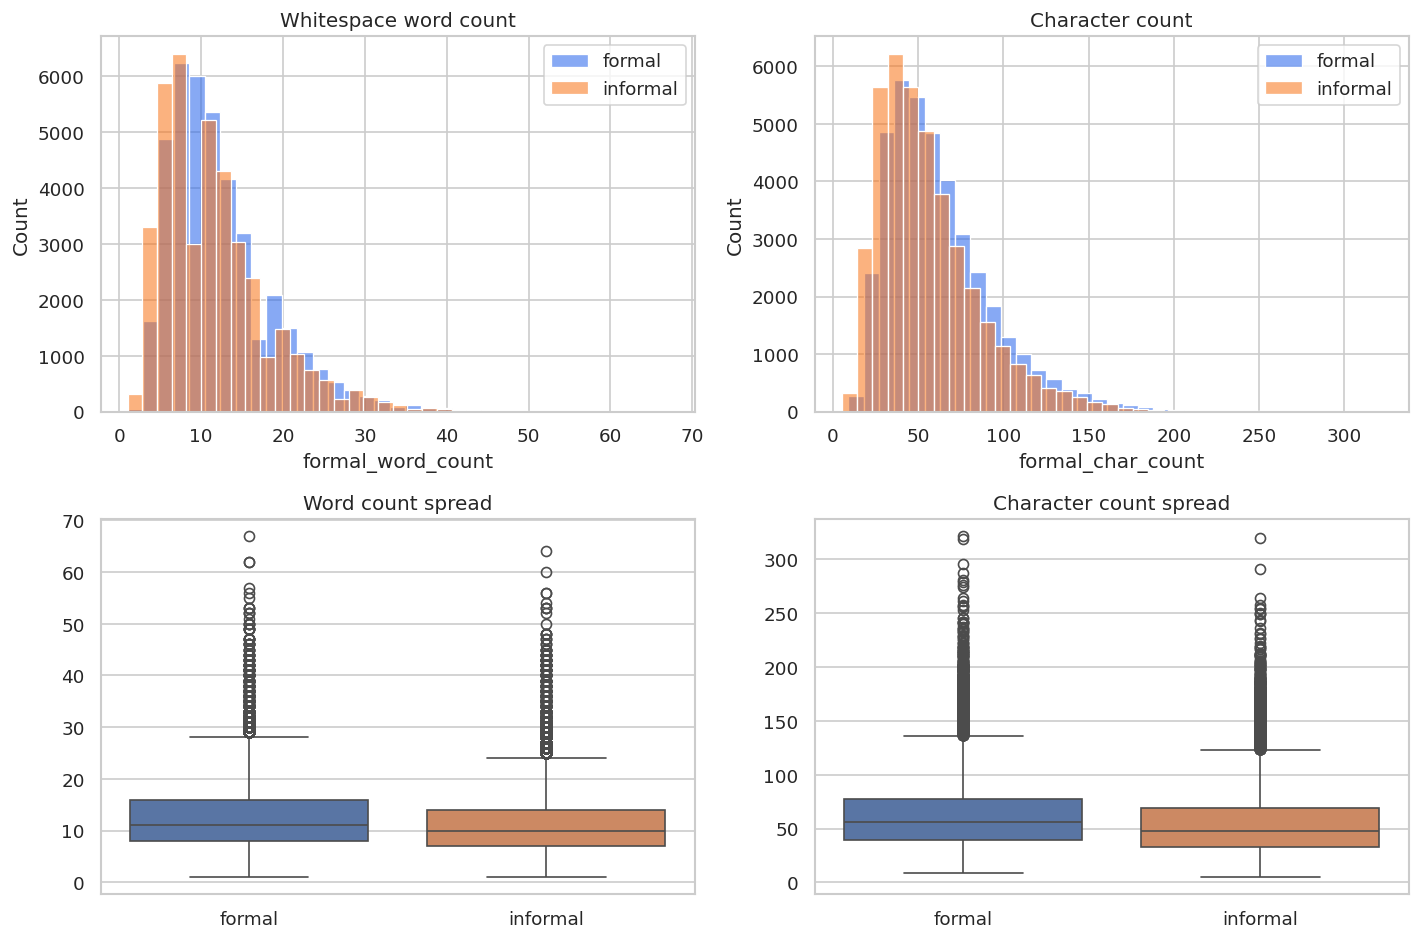

In [5]:
def whitespace_tokens(text: str) -> list[str]:
    return normalize_persian_text(text).split()

persian_word_re = re.compile(r"[\u0600-\u06FF]+(?:‌[\u0600-\u06FF]+)*|[A-Za-z0-9]+")

def lexical_tokens(text: str) -> list[str]:
    return persian_word_re.findall(normalize_persian_text(text))

df["formal_ws_tokens"] = df["formal"].map(whitespace_tokens)
df["informal_ws_tokens"] = df["informal"].map(whitespace_tokens)
df["formal_word_count"] = df["formal_ws_tokens"].map(len)
df["informal_word_count"] = df["informal_ws_tokens"].map(len)
df["formal_char_count"] = df["formal"].str.len()
df["informal_char_count"] = df["informal"].str.len()

length_cols = [
    "formal_word_count",
    "informal_word_count",
    "formal_char_count",
    "informal_char_count",
]
length_summary = df[length_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).T.round(2)
display(length_summary)

length_delta = pd.DataFrame(
    {
        "word_delta_informal_minus_formal": df["informal_word_count"] - df["formal_word_count"],
        "char_delta_informal_minus_formal": df["informal_char_count"] - df["formal_char_count"],
    }
)
display(length_delta.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T.round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["formal_word_count"], bins=35, color="#2563eb", label="formal", alpha=0.55, ax=axes[0, 0])
sns.histplot(df["informal_word_count"], bins=35, color="#f97316", label="informal", alpha=0.55, ax=axes[0, 0])
axes[0, 0].set_title("Whitespace word count")
axes[0, 0].legend()

sns.histplot(df["formal_char_count"], bins=35, color="#2563eb", label="formal", alpha=0.55, ax=axes[0, 1])
sns.histplot(df["informal_char_count"], bins=35, color="#f97316", label="informal", alpha=0.55, ax=axes[0, 1])
axes[0, 1].set_title("Character count")
axes[0, 1].legend()

sns.boxplot(data=df[["formal_word_count", "informal_word_count"]], ax=axes[1, 0])
axes[1, 0].set_title("Word count spread")
axes[1, 0].set_xticklabels(["formal", "informal"])

sns.boxplot(data=df[["formal_char_count", "informal_char_count"]], ax=axes[1, 1])
axes[1, 1].set_title("Character count spread")
axes[1, 1].set_xticklabels(["formal", "informal"])

plt.tight_layout()
plt.show()

The two sides have very similar sentence lengths, but the informal forms lean slightly shorter in many pairs. That matches the qualitative sample: informality often compresses verbs or replaces a longer formal expression with a spoken one. The overlap between distributions is still large, so length alone would be a weak classifier.

## 1.3 Vocabulary and Frequent Words

For vocabulary analysis we use a simple Persian-aware regex tokenizer. We do not remove stopwords, because words such as را/رو, است/هست, یک/یه are exactly the signals that distinguish formal and informal Persian.

,side,total_tokens,vocab_size,tokens_seen_once,type_token_ratio
0,formal,494137,36823,18936,0.0745
1,informal,456678,48130,28047,0.1054


,formal_word,formal_count,informal_word,informal_count
0,را,21184,و,14417
1,که,16439,که,12920
2,و,15588,به,8109
3,به,12619,از,7659
4,است,11590,رو,6584
5,از,9273,این,5325
6,من,8265,تو,5299
7,هم,7583,یه,5216
8,در,6819,من,4463
9,این,6094,با,4442


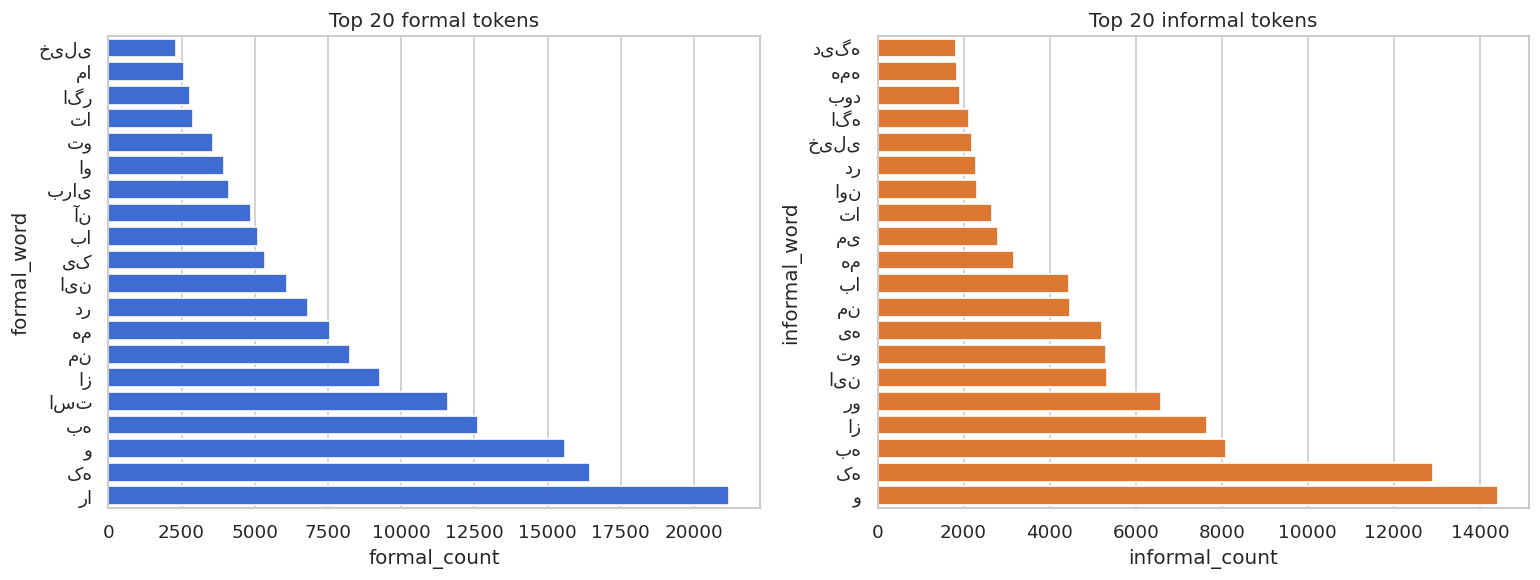

In [6]:
df["formal_tokens"] = df["formal"].map(lexical_tokens)
df["informal_tokens"] = df["informal"].map(lexical_tokens)

formal_counter = Counter(token for sent in df["formal_tokens"] for token in sent)
informal_counter = Counter(token for sent in df["informal_tokens"] for token in sent)

vocab_report = pd.DataFrame(
    {
        "side": ["formal", "informal"],
        "total_tokens": [sum(formal_counter.values()), sum(informal_counter.values())],
        "vocab_size": [len(formal_counter), len(informal_counter)],
        "tokens_seen_once": [
            sum(1 for count in formal_counter.values() if count == 1),
            sum(1 for count in informal_counter.values() if count == 1),
        ],
    }
)
vocab_report["type_token_ratio"] = (vocab_report["vocab_size"] / vocab_report["total_tokens"]).round(4)
display(vocab_report)

top_formal = pd.DataFrame(formal_counter.most_common(20), columns=["formal_word", "formal_count"])
top_informal = pd.DataFrame(informal_counter.most_common(20), columns=["informal_word", "informal_count"])
display(pd.concat([top_formal, top_informal], axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=top_formal.sort_values("formal_count"), x="formal_count", y="formal_word", ax=axes[0], color="#2563eb")
axes[0].set_title("Top 20 formal tokens")
sns.barplot(data=top_informal.sort_values("informal_count"), x="informal_count", y="informal_word", ax=axes[1], color="#f97316")
axes[1].set_title("Top 20 informal tokens")
plt.tight_layout()
plt.show()

The frequent-word lists make the style shift visible. The formal side keeps markers such as `را` and more written forms, while the informal side gives more weight to spoken markers such as `رو`, `یه`, and shorter verb spellings. Keeping these high-frequency words is useful here: they are not noise for this task, they are part of the register signal.

## 1.4 ParsBERT Tokenization and Token Inflation Factor

ParsBERT uses WordPiece subword tokenization. We compare each sentence's whitespace length with its subword length and define:

`Token Inflation Factor = number of ParsBERT subwords / number of whitespace words`

A larger value means the tokenizer has to split words more aggressively.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, local_files_only=True)
print(type(tokenizer).__name__)
print("Vocabulary size:", tokenizer.vocab_size)

token_example_rows = []
for _, row in df.sample(6, random_state=RANDOM_SEED + 1).iterrows():
    for side in ["formal", "informal"]:
        tokens = tokenizer.tokenize(row[side])
        token_example_rows.append(
            {
                "side": side,
                "text": row[side],
                "whitespace_words": len(whitespace_tokens(row[side])),
                "subwords": len(tokens),
                "first_subwords": " ".join(tokens[:30]),
            }
        )
display(pd.DataFrame(token_example_rows))

BertTokenizer
Vocabulary size: 100000


,side,text,whitespace_words,subwords,first_subwords
0,formal,شوهرت راست می‌گوید؛ چون برگرداندن آن سخت است.,8,10,شوهرت راست میگوید ؛ چون برگرداندن ان سخت است .
1,informal,شوشوت راست میگه برگردوندنش سخته.,5,9,شوش ##وت راست میگه برگرد ##وندن ##ش سخته .
2,formal,دلم مهمانی و دورهمی می‌خواهد.,5,6,دلم مهمانی و دورهمی میخواهد .
3,informal,دلم مهمونی و دورهمی میخواد,5,5,دلم مهمونی و دورهمی میخواد
4,formal,خالۀ من دیشب خواب دیده است، که مامانم به یکی از اقواممان که فوت کرده است یک گردنبند می‌دهد و به او می‌گوید زود برو ت...,35,40,خال ##ە من دیشب خواب دیده است ، که مامانم به یکی از اقوام ##مان که فوت کرده است یک گردنبند میدهد و به او میگوید زود ...
5,informal,خاله من دیشب خواب دیده که مامانم به یکی از اقواممون ک فوت کرده یه گردنبند میده و بش میگه زود برو تا ازت نگرفتنش بعد ...,29,32,خاله من دیشب خواب دیده که مامانم به یکی از اقوام ##مون ک فوت کرده یه گردنبند میده و بش میگه زود برو تا ازت نگرفتن ##...
6,formal,بعد از آن، این ایدۀ پرتوقعی دخترهای دهه‌شصتی روی سر و زبان همه افتاد.,14,21,بعد از ان ، این ایدە پرتو ##قع ##ی دخترهای دهه ##ش ##صت ##ی روی سر و زبان همه افتاد .
7,informal,بعد از اون این ایده پرتوقعی دخترای دهه شصتی افتاد رو سر و زبون همه,15,18,بعد از اون این ایده پرتو ##قع ##ی دختر ##ای دهه شصتی افتاد رو سر و زبون همه
8,formal,تا خودت شهدایی نشوی، شهدایی‌ها را تشخیص نمی‌دهی‌.,8,12,تا خودت شهدایی نشوی ، شهدایی ##ها را تشخیص نمیده ##ی .
9,informal,تا خودت شهدایی نشی.‌..شهدایی هارو تشخیص نمیدی,7,12,تا خودت شهدایی نشی . . . شهدایی هارو تشخیص نمید ##ی


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
formal_tif,40018.0,1.218,0.144,1.0,1.083,1.125,1.182,1.273,1.4,1.500,3.5
informal_tif,40018.0,1.261,0.225,1.0,1.059,1.118,1.200,1.333,1.5,1.667,9.0
formal_subword_count,40018.0,14.651,7.136,2.0,7.000,9.000,13.000,18.000,24.0,29.000,71.0
informal_subword_count,40018.0,13.736,7.097,2.0,6.000,9.000,12.000,17.000,23.0,28.000,67.0


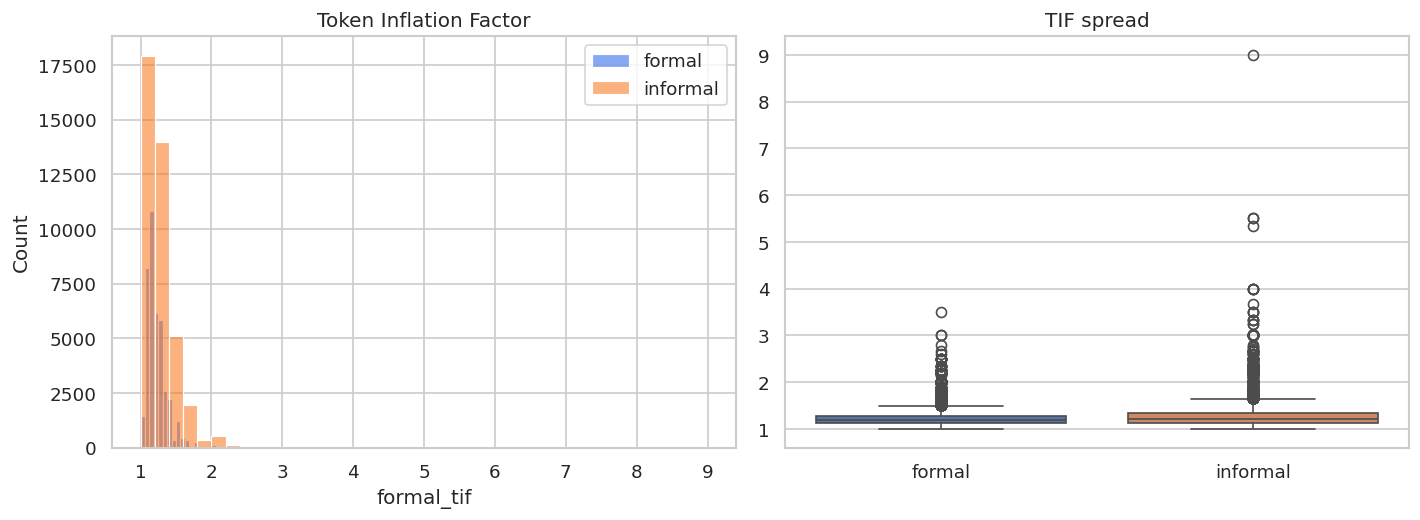

In [8]:
def batched_subword_counts(texts, batch_size: int = 512) -> np.ndarray:
    counts: list[int] = []
    texts = list(texts)
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(batch, add_special_tokens=False, padding=False, truncation=False)
        counts.extend(len(ids) for ids in encoded["input_ids"])
    return np.array(counts)

df["formal_subword_count"] = batched_subword_counts(df["formal"])
df["informal_subword_count"] = batched_subword_counts(df["informal"])
df["formal_tif"] = df["formal_subword_count"] / df["formal_word_count"].clip(lower=1)
df["informal_tif"] = df["informal_subword_count"] / df["informal_word_count"].clip(lower=1)

tif_summary = df[["formal_tif", "informal_tif", "formal_subword_count", "informal_subword_count"]].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
).T.round(3)
display(tif_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["formal_tif"], bins=40, color="#2563eb", label="formal", alpha=0.55, ax=axes[0])
sns.histplot(df["informal_tif"], bins=40, color="#f97316", label="informal", alpha=0.55, ax=axes[0])
axes[0].set_title("Token Inflation Factor")
axes[0].legend()

sns.boxplot(data=df[["formal_tif", "informal_tif"]], ax=axes[1])
axes[1].set_xticklabels(["formal", "informal"])
axes[1].set_title("TIF spread")
plt.tight_layout()
plt.show()

The inflation factors show that ParsBERT usually maps one whitespace word to more than one WordPiece token. Informal Persian can inflate when spellings are less standardized, but formal Persian can also split because of compounds and clitics. This is why we keep a fixed `max_length` later and check real tokenized pairs before training.

## 2.1 Word2Vec on the Integrated Corpus

Word2Vec learns one static vector per word from local context. We train it on the integrated corpus, meaning formal and informal sentences are pooled together. We use skip-gram (`sg=1`) because it usually handles rarer words better than CBOW, which matters for colloquial spellings.

Main choices:

- `vector_size=200`: enough capacity for this corpus without making the model too heavy.
- `window=5`: a local context window that fits sentence-level Persian paraphrases.
- `min_count=2`: removes one-off typos while keeping common informal variants.
- `negative=10`, `epochs=15`: standard negative sampling setup for stable neighborhoods.

In [9]:
from gensim.models import Word2Vec

integrated_sentences = df["formal_tokens"].tolist() + df["informal_tokens"].tolist()
workers = max(1, min(4, (os.cpu_count() or 2) - 1))

w2v_model = Word2Vec(
    sentences=integrated_sentences,
    vector_size=200,
    window=5,
    min_count=2,
    workers=workers,
    sg=1,
    negative=10,
    sample=1e-4,
    epochs=15,
    seed=RANDOM_SEED,
)

print("Word2Vec vocabulary size:", len(w2v_model.wv))
print("Vector size:", w2v_model.vector_size)

Word2Vec vocabulary size: 34137
Vector size: 200


In [10]:
target_candidates = [
    "را", "رو", "یک", "یه", "آن", "اون", "برای", "واسه",
    "اگر", "اگه", "است", "هست", "می‌شود", "میشه", "نمی‌شود", "نمیشه",
    "خانه", "خونه", "می‌روم", "میرم",
]
available_targets = [word for word in target_candidates if word in w2v_model.wv.key_to_index]
if len(available_targets) < 6:
    frequent_fallback = [word for word, _ in (formal_counter + informal_counter).most_common(30)]
    available_targets = list(dict.fromkeys(available_targets + [w for w in frequent_fallback if w in w2v_model.wv.key_to_index]))[:10]
else:
    available_targets = available_targets[:10]

neighbor_rows = []
for target in available_targets:
    for neighbor, score in w2v_model.wv.most_similar(target, topn=5):
        neighbor_rows.append(
            {
                "target": target,
                "neighbor": neighbor,
                "cosine_similarity": round(float(score), 4),
            }
        )

display(pd.DataFrame(neighbor_rows))

,target,neighbor,cosine_similarity
0,را,آن,0.7373
1,را,آن‌ها,0.7348
2,را,او,0.7206
3,را,است،,0.6624
4,را,آن‌ور,0.6552
5,رو,اون,0.6631
6,رو,هاشو,0.6321
7,رو,منو,0.6123
8,رو,ی,0.6109
9,رو,یه,0.6052


The Word2Vec neighborhoods are useful for a quick sanity check. Words with similar syntactic roles tend to cluster together, and some formal/informal variants appear near each other when they occur in similar contexts. Still, these are static word vectors: `رو` has one vector whether it is an object marker or appears in another construction, so sentence meaning has to be approximated by averaging.

## 2.2 Average Word2Vec Sentence Embeddings

For a sentence-level baseline, we average the Word2Vec vectors of all in-vocabulary tokens. We compare two groups:

- positive controls: true aligned formal/informal pairs;
- negative controls: the same formal sentences paired with randomly deranged informal sentences.

The negative construction keeps both sides realistic but breaks the alignment.

,pair_type,mean_cosine,median_cosine,std_cosine
0,positive_aligned,0.8330,0.8518,0.1090
1,random_negative,0.6272,0.6404,0.0965


,count,mean,std,min,25%,50%,75%,max
formal_coverage,500.0,0.969,0.066,0.4,0.956,1.0,1.0,1.0
informal_coverage,500.0,0.927,0.112,0.0,0.889,1.0,1.0,1.0
negative_coverage,500.0,0.927,0.112,0.0,0.889,1.0,1.0,1.0


Word2Vec cosine ROC-AUC: 0.9211


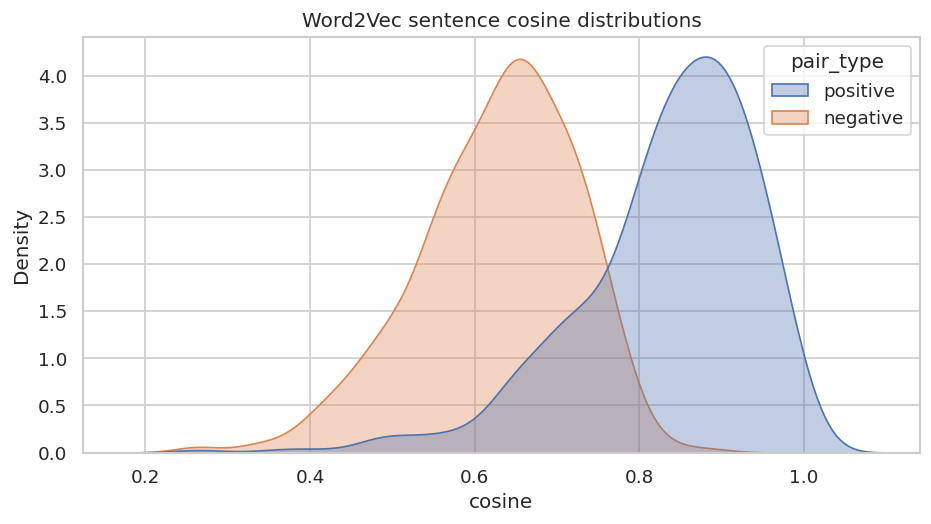

,formal,informal,w2v_positive_cosine
172,موادفروش‌ها آن‌ها را کشتند؟!,مواد فروشا کشتنشون؟!,0.264678
263,دارد آن‌ها را برعکس می‌گذارد.,داره اونا رو برعکس می ذاره.,0.363450


In [11]:
def derange(values: np.ndarray, seed: int = RANDOM_SEED) -> np.ndarray:
    values = np.asarray(values, dtype=object)
    rng = np.random.default_rng(seed)
    if len(values) < 2:
        raise ValueError("Need at least two values to create negative pairs.")
    for _ in range(100):
        shuffled = values.copy()
        rng.shuffle(shuffled)
        if not np.any(shuffled == values):
            return shuffled
    for shift in range(1, len(values)):
        shifted = np.roll(values, shift)
        if not np.any(shifted == values):
            return shifted
    raise RuntimeError("Could not derange the informal sentences.")

def average_w2v(tokens: list[str]) -> tuple[np.ndarray, float]:
    vectors = [w2v_model.wv[token] for token in tokens if token in w2v_model.wv]
    if not tokens:
        return np.zeros(w2v_model.vector_size, dtype=np.float32), 0.0
    if len(vectors) == 0:
        return np.zeros(w2v_model.vector_size, dtype=np.float32), 0.0
    return np.mean(vectors, axis=0), len(vectors) / len(tokens)

def cosine_pairwise(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    denom = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    denom = np.where(denom == 0, np.nan, denom)
    return np.sum(a * b, axis=1) / denom

CONTROL_N = min(500, len(df))
control_df = df.sample(CONTROL_N, random_state=RANDOM_SEED).reset_index(drop=True).copy()
control_df["negative_informal"] = derange(control_df["informal"].to_numpy(), seed=RANDOM_SEED + 10)
control_df["negative_informal_tokens"] = control_df["negative_informal"].map(lexical_tokens)

formal_w2v = []
informal_w2v = []
negative_w2v = []
coverage_rows = []
for _, row in control_df.iterrows():
    fv, fcov = average_w2v(row["formal_tokens"])
    iv, icov = average_w2v(row["informal_tokens"])
    nv, ncov = average_w2v(row["negative_informal_tokens"])
    formal_w2v.append(fv)
    informal_w2v.append(iv)
    negative_w2v.append(nv)
    coverage_rows.append((fcov, icov, ncov))

formal_w2v = np.vstack(formal_w2v)
informal_w2v = np.vstack(informal_w2v)
negative_w2v = np.vstack(negative_w2v)

control_df["w2v_positive_cosine"] = cosine_pairwise(formal_w2v, informal_w2v)
control_df["w2v_negative_cosine"] = cosine_pairwise(formal_w2v, negative_w2v)
coverage_df = pd.DataFrame(coverage_rows, columns=["formal_coverage", "informal_coverage", "negative_coverage"])

w2v_similarity_report = pd.DataFrame(
    {
        "pair_type": ["positive_aligned", "random_negative"],
        "mean_cosine": [
            np.nanmean(control_df["w2v_positive_cosine"]),
            np.nanmean(control_df["w2v_negative_cosine"]),
        ],
        "median_cosine": [
            np.nanmedian(control_df["w2v_positive_cosine"]),
            np.nanmedian(control_df["w2v_negative_cosine"]),
        ],
        "std_cosine": [
            np.nanstd(control_df["w2v_positive_cosine"]),
            np.nanstd(control_df["w2v_negative_cosine"]),
        ],
    }
).round(4)
display(w2v_similarity_report)
display(coverage_df.describe().T.round(3))

w2v_labels_for_auc = np.r_[np.ones(CONTROL_N), np.zeros(CONTROL_N)]
w2v_scores_for_auc = np.r_[control_df["w2v_positive_cosine"], control_df["w2v_negative_cosine"]]
finite_w2v_scores = np.isfinite(w2v_scores_for_auc)
if finite_w2v_scores.sum() > 0 and len(np.unique(w2v_labels_for_auc[finite_w2v_scores])) == 2:
    w2v_auc = roc_auc_score(w2v_labels_for_auc[finite_w2v_scores], w2v_scores_for_auc[finite_w2v_scores])
    print("Word2Vec cosine ROC-AUC:", round(float(w2v_auc), 4))
else:
    w2v_auc = np.nan
    print("Word2Vec cosine ROC-AUC: not available after filtering non-finite scores")

plot_df = pd.DataFrame(
    {
        "cosine": np.r_[control_df["w2v_positive_cosine"], control_df["w2v_negative_cosine"]],
        "pair_type": ["positive"] * CONTROL_N + ["negative"] * CONTROL_N,
    }
)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.kdeplot(data=plot_df, x="cosine", hue="pair_type", fill=True, common_norm=False, alpha=0.35, ax=ax)
ax.set_title("Word2Vec sentence cosine distributions")
plt.show()

low_w2v_pairs = control_df[control_df["w2v_positive_cosine"] < 0.4].sort_values("w2v_positive_cosine").head(12)
display(low_w2v_pairs[["formal", "informal", "w2v_positive_cosine"]])

Averaged Word2Vec separates the aligned and random pairs, but not perfectly. In this run, true aligned pairs had a mean cosine of 0.8330, while random negatives averaged 0.6272. The ROC-AUC was 0.9211 after filtering non-finite cosine values. That is a strong baseline, but the low-scoring true pairs show the weakness clearly: when the informal sentence changes several surface forms or contains rare spellings, a simple average of static word vectors loses too much information.


## 2.3 ParsBERT Sentence Embeddings

For ParsBERT, we use mean pooling over the final hidden states with the attention mask. Mean pooling is a practical sentence representation for BERT-style models and avoids relying only on the first `[CLS]` position.

Encoding unique sentences: 1000


,pair_type,mean_cosine,median_cosine,std_cosine
0,positive_aligned,0.8080,0.8145,0.0769
1,random_negative,0.5485,0.5450,0.0608


ParsBERT cosine ROC-AUC: 0.9944


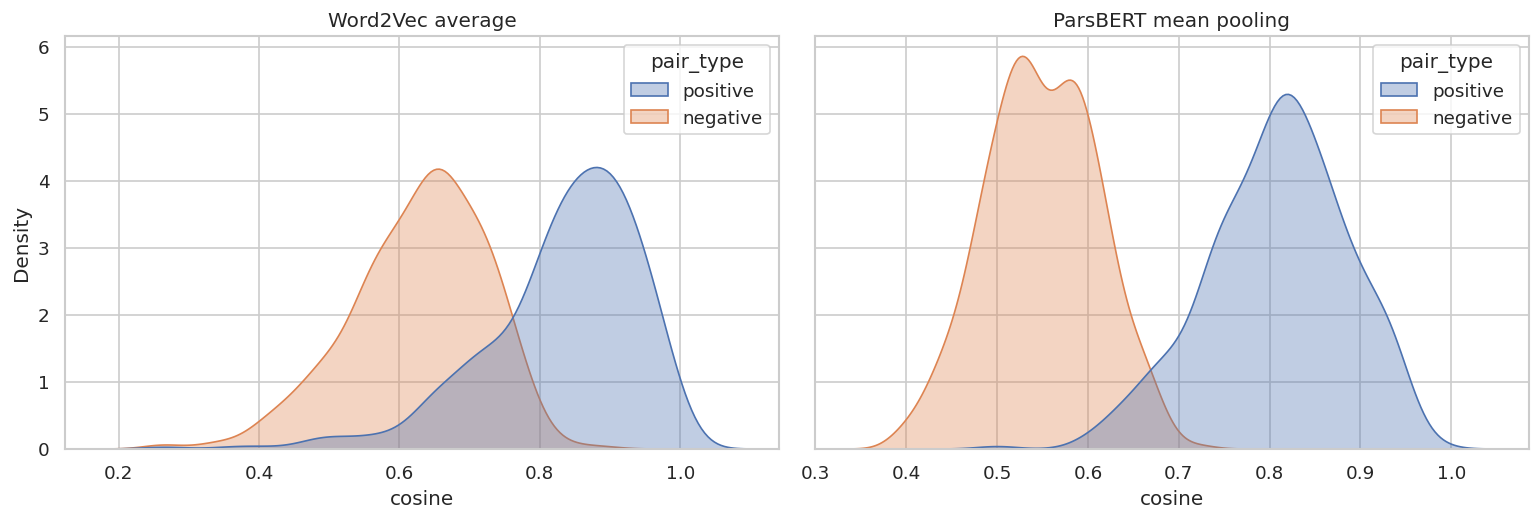

In [13]:
USE_ACCELERATION_FOR_BERT_EMBEDDINGS = True

def choose_device() -> torch.device:
    if USE_ACCELERATION_FOR_BERT_EMBEDDINGS and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = choose_device()
BERT_EMBED_BATCH_SIZE = 4 if DEVICE.type == "cuda" else 8
MAX_LENGTH = 96

def load_encoder(device: torch.device):
    kwargs = {"local_files_only": True}
    if device.type == "cuda":
        kwargs["dtype"] = torch.float16
    model = quiet_from_pretrained(AutoModel, MODEL_NAME, **kwargs).to(device)
    model.eval()
    return model

@torch.no_grad()
def encode_with_mean_pooling(texts: list[str], model, device: torch.device, batch_size: int, max_length: int) -> np.ndarray:
    vectors = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        if device.type == "cuda":
            with torch.amp.autocast("cuda", dtype=torch.float16):
                output = model(**encoded)
        else:
            output = model(**encoded)
        mask = encoded["attention_mask"].unsqueeze(-1).to(output.last_hidden_state.dtype)
        pooled = (output.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        vectors.append(pooled.float().cpu().numpy())
    return np.vstack(vectors)

unique_texts = pd.Index(
    pd.concat(
        [
            control_df["formal"],
            control_df["informal"],
            control_df["negative_informal"],
        ],
        ignore_index=True,
    )
).drop_duplicates().tolist()

print("Encoding unique sentences:", len(unique_texts))
try:
    bert_encoder = load_encoder(DEVICE)
    bert_vectors = encode_with_mean_pooling(unique_texts, bert_encoder, DEVICE, BERT_EMBED_BATCH_SIZE, MAX_LENGTH)
except RuntimeError as err:
    if "out of memory" not in str(err).lower():
        raise
    print("Accelerated embedding ran out of memory; retrying with the safer setting.")
    del bert_encoder
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    DEVICE = torch.device("cpu")
    BERT_EMBED_BATCH_SIZE = 8
    bert_encoder = load_encoder(DEVICE)
    bert_vectors = encode_with_mean_pooling(unique_texts, bert_encoder, DEVICE, BERT_EMBED_BATCH_SIZE, MAX_LENGTH)

bert_vector_map = dict(zip(unique_texts, bert_vectors))
formal_bert = np.vstack([bert_vector_map[text] for text in control_df["formal"]])
informal_bert = np.vstack([bert_vector_map[text] for text in control_df["informal"]])
negative_bert = np.vstack([bert_vector_map[text] for text in control_df["negative_informal"]])

control_df["bert_positive_cosine"] = cosine_pairwise(formal_bert, informal_bert)
control_df["bert_negative_cosine"] = cosine_pairwise(formal_bert, negative_bert)

bert_similarity_report = pd.DataFrame(
    {
        "pair_type": ["positive_aligned", "random_negative"],
        "mean_cosine": [
            np.nanmean(control_df["bert_positive_cosine"]),
            np.nanmean(control_df["bert_negative_cosine"]),
        ],
        "median_cosine": [
            np.nanmedian(control_df["bert_positive_cosine"]),
            np.nanmedian(control_df["bert_negative_cosine"]),
        ],
        "std_cosine": [
            np.nanstd(control_df["bert_positive_cosine"]),
            np.nanstd(control_df["bert_negative_cosine"]),
        ],
    }
).round(4)
display(bert_similarity_report)

bert_auc = roc_auc_score(
    np.r_[np.ones(CONTROL_N), np.zeros(CONTROL_N)],
    np.r_[control_df["bert_positive_cosine"], control_df["bert_negative_cosine"]],
)
print("ParsBERT cosine ROC-AUC:", round(float(bert_auc), 4))

comparison_df = pd.concat(
    [
        pd.DataFrame({"model": "Word2Vec average", "pair_type": "positive", "cosine": control_df["w2v_positive_cosine"]}),
        pd.DataFrame({"model": "Word2Vec average", "pair_type": "negative", "cosine": control_df["w2v_negative_cosine"]}),
        pd.DataFrame({"model": "ParsBERT mean pooling", "pair_type": "positive", "cosine": control_df["bert_positive_cosine"]}),
        pd.DataFrame({"model": "ParsBERT mean pooling", "pair_type": "negative", "cosine": control_df["bert_negative_cosine"]}),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, model_name in zip(axes, ["Word2Vec average", "ParsBERT mean pooling"]):
    sns.kdeplot(
        data=comparison_df[comparison_df["model"] == model_name],
        x="cosine",
        hue="pair_type",
        fill=True,
        common_norm=False,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(model_name)
plt.tight_layout()
plt.show()

del bert_encoder
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

ParsBERT gives a cleaner separation than Word2Vec. The aligned pairs had a mean cosine of 0.8080, while the random negatives averaged 0.5485, and the ROC-AUC rose to 0.9944. The absolute cosine values are not directly comparable to Word2Vec because BERT sentence spaces are anisotropic, but the distribution gap is much larger. This fits the task well: contextual embeddings are less brittle when informality changes spelling, morphology, or word order.


## 2.4 PCA and t-SNE Visualization

We visualize 30 aligned pairs. Formal and informal points are colored separately, and a thin line connects each true pair. We make both PCA and t-SNE plots for Word2Vec and ParsBERT.

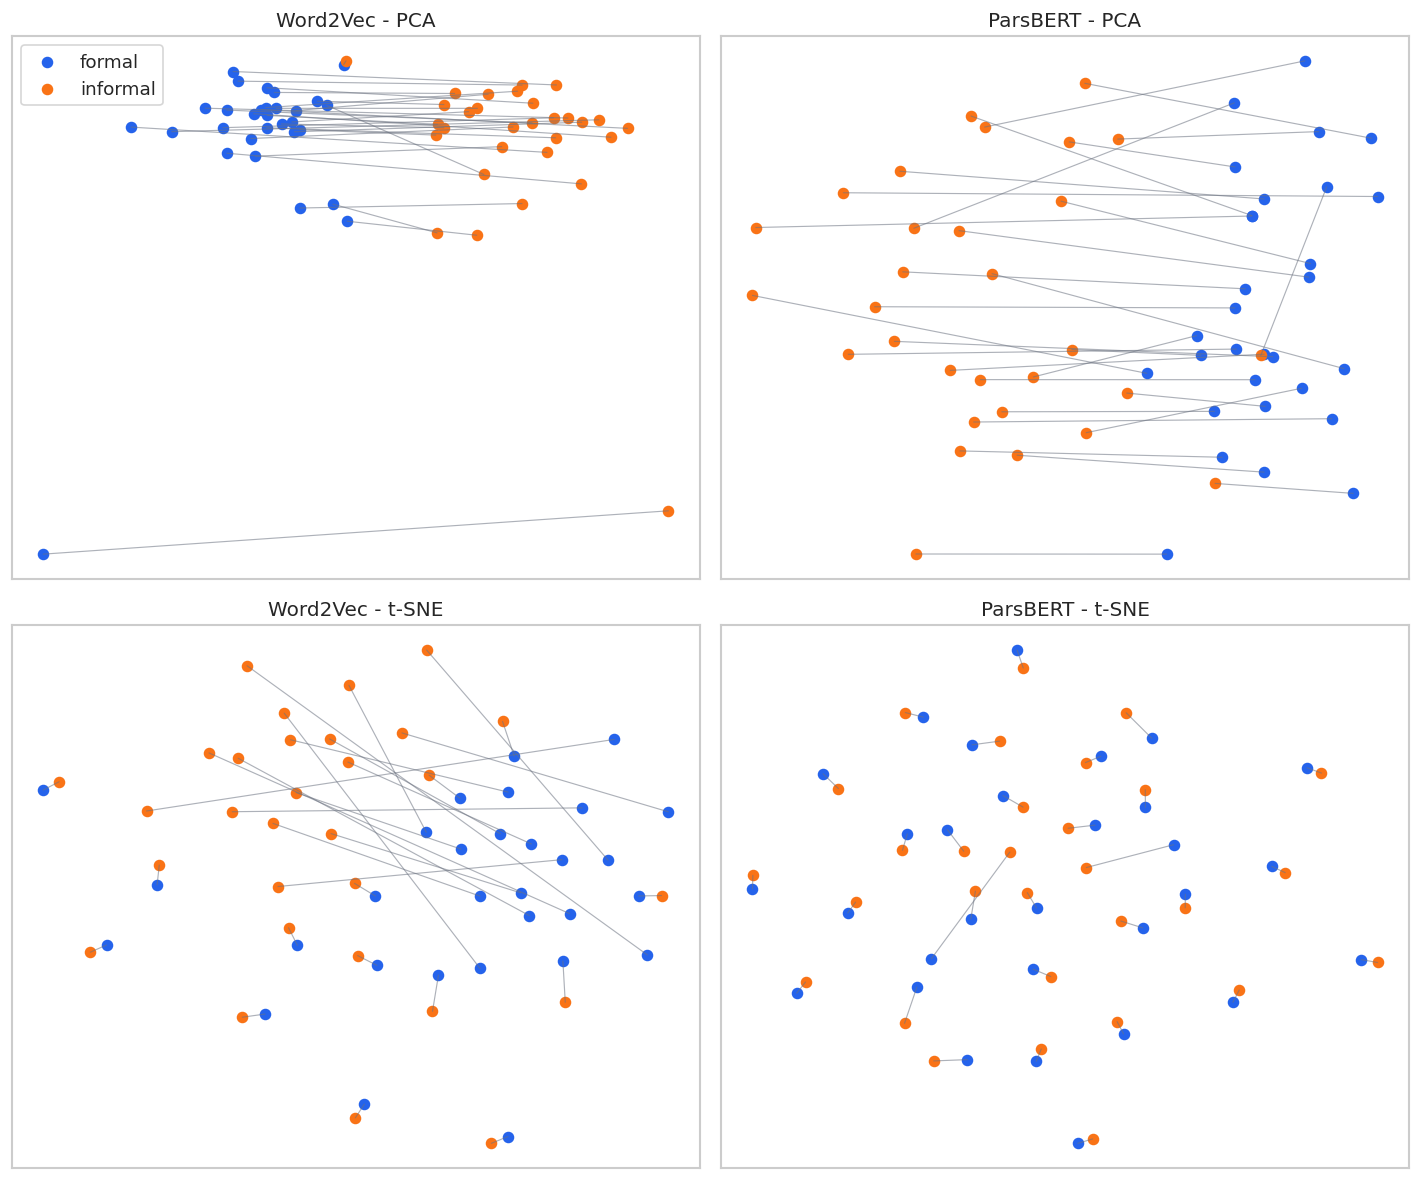

In [15]:
vis_df = control_df.head(30).copy().reset_index(drop=True)

vis_w2v_formal = np.vstack([formal_w2v[i] for i in range(len(vis_df))])
vis_w2v_informal = np.vstack([informal_w2v[i] for i in range(len(vis_df))])
vis_bert_formal = np.vstack([bert_vector_map[text] for text in vis_df["formal"]])
vis_bert_informal = np.vstack([bert_vector_map[text] for text in vis_df["informal"]])

def pca_2d(matrix: np.ndarray) -> np.ndarray:
    return PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(matrix)

def tsne_2d(matrix: np.ndarray) -> np.ndarray:
    pre_dim = min(50, matrix.shape[1], matrix.shape[0] - 1)
    matrix_for_tsne = PCA(n_components=pre_dim, random_state=RANDOM_SEED).fit_transform(matrix) if pre_dim > 2 else matrix
    perplexity = min(10, max(2, (matrix.shape[0] - 1) // 3))
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=RANDOM_SEED,
    ).fit_transform(matrix_for_tsne)

def plot_pairs(ax, points: np.ndarray, title: str):
    n = len(points) // 2
    formal_points = points[:n]
    informal_points = points[n:]
    ax.scatter(formal_points[:, 0], formal_points[:, 1], c="#2563eb", label="formal", s=35)
    ax.scatter(informal_points[:, 0], informal_points[:, 1], c="#f97316", label="informal", s=35)
    for i in range(n):
        ax.plot(
            [formal_points[i, 0], informal_points[i, 0]],
            [formal_points[i, 1], informal_points[i, 1]],
            c="#6b7280",
            linewidth=0.7,
            alpha=0.55,
        )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

w2v_points = np.vstack([vis_w2v_formal, vis_w2v_informal])
bert_points = np.vstack([vis_bert_formal, vis_bert_informal])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_pairs(axes[0, 0], pca_2d(w2v_points), "Word2Vec - PCA")
plot_pairs(axes[0, 1], pca_2d(bert_points), "ParsBERT - PCA")
plot_pairs(axes[1, 0], tsne_2d(w2v_points), "Word2Vec - t-SNE")
plot_pairs(axes[1, 1], tsne_2d(bert_points), "ParsBERT - t-SNE")
axes[0, 0].legend(loc="best")
plt.tight_layout()
plt.show()

The PCA plots are useful for broad structure, while t-SNE emphasizes local neighborhoods. In Word2Vec space, some connected pairs stretch far apart when a colloquial rewrite changes several tokens. ParsBERT usually keeps more of those links shorter, although the space is still not a perfect map of equivalence. The visualization supports the numerical comparison: contextual embeddings are less brittle than averaged word vectors.

## 3.1 Leakage-Safe Positive and Negative Pair Construction

We construct binary data with a strict 1:1 balance:

- label `1`: original aligned formal/informal pair;
- label `0`: formal sentence paired with a different informal sentence from the same split.

The split is done before negative sampling. We also remove sentence texts that appear more than once anywhere in the pair table, so the same sentence cannot appear in train and test under a different partner.

In [16]:
pair_df = df[["formal", "informal"]].drop_duplicates().reset_index(drop=True).copy()
pair_df["formal_norm"] = pair_df["formal"].map(normalize_persian_text)
pair_df["informal_norm"] = pair_df["informal"].map(normalize_persian_text)
pair_df = pair_df[pair_df["formal_norm"] != pair_df["informal_norm"]].copy()

all_sentence_counts = Counter(pair_df["formal_norm"].tolist() + pair_df["informal_norm"].tolist())
strict_pairs = pair_df[
    pair_df["formal_norm"].map(all_sentence_counts).eq(1)
    & pair_df["informal_norm"].map(all_sentence_counts).eq(1)
].reset_index(drop=True)

train_pos, temp_pos = train_test_split(strict_pairs, test_size=0.2, random_state=RANDOM_SEED, shuffle=True)
val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=RANDOM_SEED, shuffle=True)

def build_labeled_split(pos: pd.DataFrame, split_name: str, seed: int) -> pd.DataFrame:
    pos = pos.reset_index(drop=True).copy()
    neg_informal = derange(pos["informal"].to_numpy(), seed=seed)
    positives = pd.DataFrame(
        {
            "formal": pos["formal"],
            "informal": pos["informal"],
            "label": 1,
            "split": split_name,
            "source": "aligned",
        }
    )
    negatives = pd.DataFrame(
        {
            "formal": pos["formal"],
            "informal": neg_informal,
            "label": 0,
            "split": split_name,
            "source": "deranged_negative",
        }
    )
    out = pd.concat([positives, negatives], ignore_index=True)
    return out.sample(frac=1, random_state=seed).reset_index(drop=True)

train_pairs = build_labeled_split(train_pos, "train", RANDOM_SEED + 101)
val_pairs = build_labeled_split(val_pos, "validation", RANDOM_SEED + 102)
test_pairs = build_labeled_split(test_pos, "test", RANDOM_SEED + 103)

def sentence_set(frame: pd.DataFrame) -> set[str]:
    return set(frame["formal"].map(normalize_persian_text)) | set(frame["informal"].map(normalize_persian_text))

split_sets = {
    "train": sentence_set(train_pairs),
    "validation": sentence_set(val_pairs),
    "test": sentence_set(test_pairs),
}

assert split_sets["train"].isdisjoint(split_sets["validation"])
assert split_sets["train"].isdisjoint(split_sets["test"])
assert split_sets["validation"].isdisjoint(split_sets["test"])

split_report = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(frame),
            "positive": int((frame["label"] == 1).sum()),
            "negative": int((frame["label"] == 0).sum()),
            "unique_sentences": len(sentence_set(frame)),
        }
        for name, frame in [("train", train_pairs), ("validation", val_pairs), ("test", test_pairs)]
    ]
)
cleanup_report = pd.DataFrame(
    {
        "stage": ["original_pairs_after_drop_duplicates", "strict_no_repeated_sentence_pairs"],
        "pairs": [len(pair_df), len(strict_pairs)],
    }
)
display(cleanup_report)
display(split_report)

,stage,pairs
0,original_pairs_after_drop_duplicates,39989
1,strict_no_repeated_sentence_pairs,39809


,split,rows,positive,negative,unique_sentences
0,train,63694,31847,31847,63694
1,validation,7962,3981,3981,7962
2,test,7962,3981,3981,7962


This split is stricter than a basic row split. It keeps 39,809 positive pairs after duplicate and repeated-sentence filtering, then creates balanced positive/negative data inside each split. The final sizes are 63,694 train rows, 7,962 validation rows, and 7,962 test rows. The negative examples are created only after splitting, so no sentence is borrowed across train, validation, and test.


## 3.2 A Tokenized Pair

BERT-style sequence classification feeds both sentences into one sequence:

`[CLS] formal sentence [SEP] informal sentence [SEP]`

The tokenizer returns the token ids, the attention mask, and segment ids (`token_type_ids`) that mark which side each token belongs to.

In [18]:
sample_pair = train_pairs.iloc[0]
sample_encoding = tokenizer(
    sample_pair["formal"],
    sample_pair["informal"],
    padding="max_length",
    truncation=True,
    max_length=48,
)
sample_tokens = tokenizer.convert_ids_to_tokens(sample_encoding["input_ids"])
token_table = pd.DataFrame(
    {
        "position": list(range(len(sample_tokens))),
        "token": sample_tokens,
        "input_id": sample_encoding["input_ids"],
        "attention_mask": sample_encoding["attention_mask"],
        "token_type_id": sample_encoding.get("token_type_ids", [0] * len(sample_tokens)),
    }
)
display(pd.DataFrame([sample_pair[["formal", "informal", "label", "source"]]]))
display(token_table[token_table["attention_mask"] == 1].head(48))

,formal,informal,label,source
0,بیشتر کارایی واکسن آسترازنکا روحی است.,یعنی پسره میخاد بگه شارج گوشیش تموم شد,0,deranged_negative


,position,token,input_id,attention_mask,token_type_id
0,0,[CLS],2,1,0
1,1,بیشتر,3130,1,0
2,2,کارایی,7863,1,0
3,3,واکسن,12156,1,0
4,4,استراز,66098,1,0
5,5,##نک,26918,1,0
6,6,##ا,2006,1,0
7,7,روحی,8492,1,0
8,8,است,2806,1,0
9,9,.,1012,1,0


`input_ids` are the integer vocabulary indices consumed by ParsBERT. `attention_mask` is `1` for real tokens and `0` for padding, so the model does not attend to padded positions. `token_type_ids` are `0` for the first sentence and `1` for the second sentence, which helps BERT distinguish the formal side from the informal side.

## 3.3 Training the ParsBERT Sequence Classifier

We use `AutoModelForSequenceClassification` with two output labels. The optimizer is AdamW, the learning rate is set in the training configuration below, and the scheduler is linear with a warmup phase. To keep the run practical, the lower ParsBERT layers are frozen and the final encoder block plus the classification head are updated. This still trains the sentence-pair model end-to-end through ParsBERT's final block, while avoiding unnecessary computation in the earlier layers.

In [19]:
TRAIN_EXAMPLES_PER_CLASS = 500
EPOCHS = 2
TRAIN_BATCH_SIZE = 2
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
TRAINABLE_LAST_LAYERS = 1
USE_ACCELERATION_FOR_TRAINING = True

def balanced_training_subset(frame: pd.DataFrame, n_per_class: int | None) -> pd.DataFrame:
    if n_per_class is None:
        return frame.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    chunks = []
    for label, group in frame.groupby("label"):
        chunks.append(group.sample(min(n_per_class, len(group)), random_state=RANDOM_SEED + int(label)))
    return pd.concat(chunks, ignore_index=True).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

train_fit_pairs = balanced_training_subset(train_pairs, TRAIN_EXAMPLES_PER_CLASS)

pd.DataFrame(
    {
        "dataset": ["train_fit_subset", "validation_full", "test_full"],
        "rows": [len(train_fit_pairs), len(val_pairs), len(test_pairs)],
        "positive": [
            int((train_fit_pairs["label"] == 1).sum()),
            int((val_pairs["label"] == 1).sum()),
            int((test_pairs["label"] == 1).sum()),
        ],
        "negative": [
            int((train_fit_pairs["label"] == 0).sum()),
            int((val_pairs["label"] == 0).sum()),
            int((test_pairs["label"] == 0).sum()),
        ],
    }
)

,dataset,rows,positive,negative
0,train_fit_subset,1000,500,500
1,validation_full,7962,3981,3981
2,test_full,7962,3981,3981


,setting,value
0,train examples per class,5.000000e+02
1,epochs,2.000000e+00
2,train batch size,2.000000e+00
3,eval batch size,1.600000e+01
4,learning rate,2.000000e-05
5,weight decay,1.000000e-02
6,trainable parameters,7.089410e+06
7,total parameters,1.628429e+08


,epoch,step,train_loss_recent
0,1,125,0.3965
1,1,250,0.0825
2,1,375,0.0416
3,1,500,0.1425
4,2,125,0.0288
5,2,250,0.1085
6,2,375,0.0363
7,2,500,0.1124


,epoch,train_loss,val_loss
0,1,0.1658,0.0871
1,2,0.0715,0.1016


Training time: 1.98 minutes


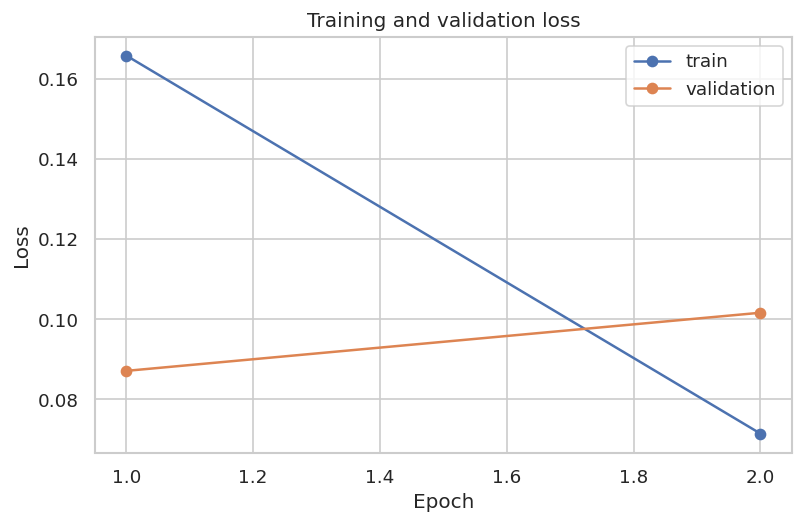

In [20]:
class PairClassificationDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tokenizer, max_length: int):
        self.labels = frame["label"].astype(int).to_numpy()
        self.encodings = tokenizer(
            frame["formal"].tolist(),
            frame["informal"].tolist(),
            padding="max_length",
            truncation=True,
            max_length=max_length,
        )

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        item = {key: torch.tensor(value[idx]) for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def make_loader(frame: pd.DataFrame, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = PairClassificationDataset(frame, tokenizer, MAX_LENGTH)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=torch.cuda.is_available(),
    )

train_loader = make_loader(train_fit_pairs, TRAIN_BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_pairs, EVAL_BATCH_SIZE, shuffle=False)
test_loader = make_loader(test_pairs, EVAL_BATCH_SIZE, shuffle=False)

CLASSIFIER_DEVICE = torch.device("cuda" if USE_ACCELERATION_FOR_TRAINING and torch.cuda.is_available() else "cpu")

def load_classifier(device: torch.device):
    model = quiet_from_pretrained(
        AutoModelForSequenceClassification,
        MODEL_NAME,
        num_labels=2,
        local_files_only=True,
    ).to(device)

    for param in model.bert.parameters():
        param.requires_grad = False
    for layer in model.bert.encoder.layer[-TRAINABLE_LAST_LAYERS:]:
        for param in layer.parameters():
            param.requires_grad = True

    trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
    total_params = sum(param.numel() for param in model.parameters())
    training_config = pd.DataFrame(
        {
            "setting": [
                "train examples per class",
                "epochs",
                "train batch size",
                "eval batch size",
                "learning rate",
                "weight decay",
                "trainable parameters",
                "total parameters",
            ],
            "value": [
                TRAIN_EXAMPLES_PER_CLASS,
                EPOCHS,
                TRAIN_BATCH_SIZE,
                EVAL_BATCH_SIZE,
                LEARNING_RATE,
                WEIGHT_DECAY,
                trainable_params,
                total_params,
            ],
        }
    )
    display(training_config)
    return model

classifier_model = load_classifier(CLASSIFIER_DEVICE)
optimizer = torch.optim.AdamW(
    [param for param in classifier_model.parameters() if param.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.1 * total_steps)),
    num_training_steps=total_steps,
)

def move_batch(batch: dict[str, torch.Tensor], device: torch.device) -> dict[str, torch.Tensor]:
    return {key: value.to(device, non_blocking=True) for key, value in batch.items()}

@torch.no_grad()
def evaluate_loss(model, loader, device: torch.device) -> float:
    model.eval()
    losses = []
    for batch in loader:
        batch = move_batch(batch, device)
        output = model(**batch)
        losses.append(float(output.loss.detach().cpu()))
    return float(np.mean(losses))

history = {"epoch": [], "train_loss": [], "val_loss": []}
step_logs = []
best_val_loss = math.inf
best_state = None
log_interval = max(1, len(train_loader) // 4)

start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    classifier_model.train()
    running_losses = []
    for step, batch in enumerate(train_loader, start=1):
        batch = move_batch(batch, CLASSIFIER_DEVICE)
        optimizer.zero_grad(set_to_none=True)
        output = classifier_model(**batch)
        loss = output.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [param for param in classifier_model.parameters() if param.requires_grad],
            max_norm=1.0,
        )
        optimizer.step()
        scheduler.step()

        loss_value = float(loss.detach().cpu())
        running_losses.append(loss_value)
        if step % log_interval == 0 or step == len(train_loader):
            step_logs.append(
                {
                    "epoch": epoch,
                    "step": step,
                    "train_loss_recent": float(np.mean(running_losses[-log_interval:])),
                }
            )

    epoch_train_loss = float(np.mean(running_losses))
    epoch_val_loss = evaluate_loss(classifier_model, val_loader, CLASSIFIER_DEVICE)
    history["epoch"].append(epoch)
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in classifier_model.state_dict().items()}

if best_state is not None:
    classifier_model.load_state_dict(best_state)
    classifier_model.to(CLASSIFIER_DEVICE)

elapsed = time.time() - start_time
history_df = pd.DataFrame(history)
step_log_df = pd.DataFrame(step_logs)

display(step_log_df.round(4))
display(history_df.round(4))
print(f"Training time: {elapsed / 60:.2f} minutes")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and validation loss")
ax.legend()
plt.show()

The loss curves are the main convergence check. Training loss moves from 0.1658 to 0.0715, while validation loss moves from 0.0871 to 0.1016. The step-level log above gives a more granular view inside each epoch. The run uses 1,000 balanced training rows, and the validation loss is computed on the full 7,962-row validation split.


## 3.4 Test Evaluation, Error Analysis, and Live Prediction

We evaluate on the full held-out test split and report accuracy, precision, recall, and macro F1. Then we inspect confident true positives/true negatives and the most confident false positives/false negatives.

,metric,value
0,accuracy,0.9770
1,precision_macro,0.9771
2,recall_macro,0.9770
3,f1_macro,0.9770
4,test_loss,0.0844


                precision    recall  f1-score   support

not_equivalent     0.9710    0.9834    0.9772      3981
    equivalent     0.9832    0.9706    0.9769      3981

      accuracy                         0.9770      7962
     macro avg     0.9771    0.9770    0.9770      7962
  weighted avg     0.9771    0.9770    0.9770      7962



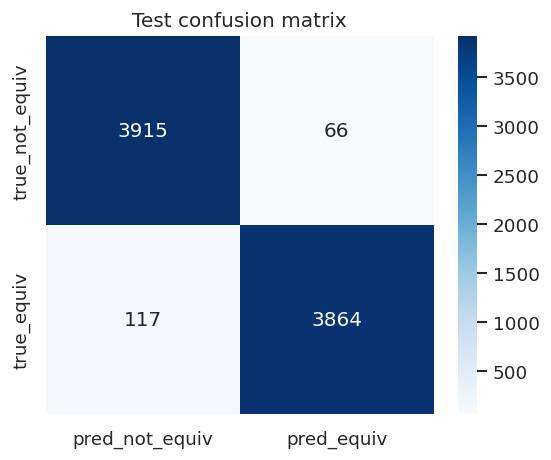

Confident true positives


,formal,informal,prob_equivalent,outcome
293,خواستم بگویم ما انتظاراتمان بیشتر از این‌ها است.,خواستم بگم ما انتظاراتمون بیشتر از ایناستا.,0.998862,TP
2919,مامانم همیشه من را با خودش به مسجد و روضه و مراسم‌ها می‌برد.,مامانم همیشه منو با خودش مسجد و روضه و مراسما میبرد,0.998857,TP
72,من مطمئنم بابا با این کار که تو می‌گویی کوتاه نمی‌آید.,من مطمئن‌م با این کار که تو می‌گی بابا کوتاه نمی‌آد.,0.998851,TP
3160,من را ببخشید ولی خاک بر سر هوادارانی کنم که باز هم مظلومی را تشویق می‌کنند، بابا مثل روز روشن است که ما در زمین هیچ ...,منو ببخشید ولی خاک بر سر هوادارانی کنم که بازم مظلومی رو تشویق میکنن بابا مثل روز روشنه که ما تو زمین هیچ برنامه ای ...,0.998849,TP
4190,هیچ‌کس با یک بار شنیدن این حرف‌ها تغییر فاز نمی‌دهد، ولی برای یک ساعت حالش خوب است.,هیچکس با یه بار شنیدن این حرفا تغییر فاز نمیده ولی برا یه ساعت حالش خوبه,0.998846,TP


Confident true negatives


,formal,informal,prob_equivalent,outcome
7506,شاید یک بار گندمشان را به دریا ریخته باشند.,نذار اون دنیا شرمندت بشم,0.001167,TN
1234,کتاب هایی که سفارش دادم هنوز نیامده است,بخدا اخر دیوونه می‌شم با کارا و زخم زبوناش.,0.001181,TN
3117,رئیس من را فرزندخوانده‌اش کرده است؛ ولی من خانواده‌ام را می‌خواهم.,انگار تونستی خودتو عادت بدی به بیدار شدن,0.001202,TN
296,یارانۀ محبت‌هایت را قطع نکن، من زیر خط‌فقر مهربانی‌هایت هستم.,یه بچه کارگر از پایین شهر فقر و ترس و سییاهی همراهشه,0.001218,TN
972,هیچ‌وقت شده است دختربچۀ پنج‌ساله با آن رنگ‌ورو جلوی تو بیاید؟,هروقت می بینمشون نمی تونم تو صورتشون نگاه کنم!,0.001221,TN


Most confident false positives


,formal,informal,prob_equivalent,outcome
2869,یک لحظه امان بده من هم حرف بزنم.,من اگه فقط بدونم کاری که می‌کنم تو رو خوش‌حال می‌کنه حاضرم تا صبح همین‌جوری حرف بزنم.,0.998136,FP
6895,خدا تو را به جهنم می‌اندازد؟,گاها چقدر خوب میشد یه به جهنم پای تمام حرفای اطرافیانم میزدم تا انقدر خودخوری نمیکردم و به این حال و روز نمیفتادم,0.997556,FP
1227,آبجی جانم! این لباسم قشنگ است؟,تمام لباسامو انداخت تو یه ساک و ساکو پرت کرد بیرون اتاق,0.997258,FP
4601,داداش رضا! یک چیزی خیلی من را اذیت می‌کند، من جدیداً دانسته گناه می‌کنم.,_داداش اون قسمتی که بچه ها گفتند شاهرخ هزار جور زن با خودش به خونه میاره هم شنیدی؟,0.996827,FP
2304,آن طفلک چشم‌وگوش‌بسته است.,چند ساله من از این خط چشم استفاده میکنم,0.996597,FP


Most confident false negatives


,formal,informal,prob_equivalent,outcome
2786,من یک دانه هستم، آن هم برای نمونه هستم.,من یه دونم اونم واسه نمونم,0.001668,FN
2804,دیگر نمی‌توانم آن را بگیرم.,دیگه نمی تونم بگیرمش,0.001807,FN
6203,اگر دست‌شویی داری، بگویم: یک جا نگه دارد.,اگه دسشویی داری بگم یه جانگه داره.,0.001934,FN
4554,خودتان می‌دانید با چه‌کسانی هستم؛ پس بعضی‌ها نیایند به خودشان بگیرند.,خودتون میدونین با کیام پس بعضیا نیان ب خودشون بگیرن,0.001938,FN
159,مثل اینکه اوضاعت ردیف نیست!,مثه اینکه اوضات ریدیف نیس,0.001984,FN


,formal_sentence,informal_sentence,equivalent_probability,predicted_label,prediction
0,من امروز به دانشگاه می‌روم.,من امروز میرم دانشگاه.,0.9974,1,equivalent
1,لطفا در را ببندید.,لطفا درو ببند.,0.9833,1,equivalent
2,او دیروز کتاب خرید.,هوا امروز خیلی گرم است.,0.0031,0,not_equivalent
3,این فیلم بسیار جذاب بود.,این فیلم خیلی قشنگ بود.,0.9892,1,equivalent


,rows_loaded,strict_pairs,train_rows,val_rows,test_rows,train_fit_rows,w2v_auc,bert_auc,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_loss,best_val_loss,training_minutes,outcome_counts
0,40018,39809,63694,7962,7962,1000,0.921089,0.99444,0.977016,0.977094,0.977016,0.977015,0.084392,0.087123,1.978398,"{'TN': 3915, 'TP': 3864, 'FN': 117, 'FP': 66}"


In [22]:
@torch.no_grad()
def predict_frame(model, loader, device: torch.device):
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []
    all_losses = []
    for batch in loader:
        labels = batch["labels"].numpy()
        batch = move_batch(batch, device)
        if device.type == "cuda":
            with torch.amp.autocast("cuda", dtype=torch.float16):
                output = model(**batch)
        else:
            output = model(**batch)
        probs = torch.softmax(output.logits.float(), dim=-1)[:, 1].detach().cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(labels)
        all_losses.append(float(output.loss.detach().cpu()))
    return {
        "prob_equivalent": np.concatenate(all_probs),
        "pred": np.concatenate(all_preds),
        "label": np.concatenate(all_labels),
        "loss": float(np.mean(all_losses)),
    }

test_pred = predict_frame(classifier_model, test_loader, CLASSIFIER_DEVICE)
y_true = test_pred["label"]
y_pred = test_pred["pred"]
y_prob = test_pred["prob_equivalent"]

metrics_report = pd.DataFrame(
    {
        "metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro", "test_loss"],
        "value": [
            accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, average="macro", zero_division=0),
            recall_score(y_true, y_pred, average="macro", zero_division=0),
            f1_score(y_true, y_pred, average="macro", zero_division=0),
            test_pred["loss"],
        ],
    }
)
display(metrics_report.round(4))
print(classification_report(y_true, y_pred, target_names=["not_equivalent", "equivalent"], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4.8, 4.0))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred_not_equiv", "pred_equiv"],
    yticklabels=["true_not_equiv", "true_equiv"],
    ax=ax,
)
ax.set_title("Test confusion matrix")
plt.tight_layout()
plt.show()

analysis_test = test_pairs.copy()
analysis_test["prob_equivalent"] = y_prob
analysis_test["prediction"] = y_pred
analysis_test["outcome"] = np.select(
    [
        (analysis_test["label"] == 1) & (analysis_test["prediction"] == 1),
        (analysis_test["label"] == 0) & (analysis_test["prediction"] == 0),
        (analysis_test["label"] == 0) & (analysis_test["prediction"] == 1),
        (analysis_test["label"] == 1) & (analysis_test["prediction"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="?",
)

print("Confident true positives")
display(analysis_test[analysis_test["outcome"] == "TP"].sort_values("prob_equivalent", ascending=False).head(5)[
    ["formal", "informal", "prob_equivalent", "outcome"]
])
print("Confident true negatives")
display(analysis_test[analysis_test["outcome"] == "TN"].sort_values("prob_equivalent", ascending=True).head(5)[
    ["formal", "informal", "prob_equivalent", "outcome"]
])
print("Most confident false positives")
display(analysis_test[analysis_test["outcome"] == "FP"].sort_values("prob_equivalent", ascending=False).head(5)[
    ["formal", "informal", "prob_equivalent", "outcome"]
])
print("Most confident false negatives")
display(analysis_test[analysis_test["outcome"] == "FN"].sort_values("prob_equivalent", ascending=True).head(5)[
    ["formal", "informal", "prob_equivalent", "outcome"]
])

def predict_equivalence(formal_sentence: str, informal_sentence: str) -> dict:
    classifier_model.eval()
    encoded = tokenizer(
        normalize_persian_text(formal_sentence),
        normalize_persian_text(informal_sentence),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    encoded = {key: value.to(CLASSIFIER_DEVICE) for key, value in encoded.items()}
    with torch.no_grad():
        if CLASSIFIER_DEVICE.type == "cuda":
            with torch.amp.autocast("cuda", dtype=torch.float16):
                output = classifier_model(**encoded)
        else:
            output = classifier_model(**encoded)
        prob = float(torch.softmax(output.logits.float(), dim=-1)[0, 1].detach().cpu())
    return {
        "equivalent_probability": round(prob, 4),
        "predicted_label": int(prob >= 0.5),
        "prediction": "equivalent" if prob >= 0.5 else "not_equivalent",
    }

demo_pairs = [
    ("من امروز به دانشگاه می‌روم.", "من امروز میرم دانشگاه."),
    ("لطفا در را ببندید.", "لطفا درو ببند."),
    ("او دیروز کتاب خرید.", "هوا امروز خیلی گرم است."),
    ("این فیلم بسیار جذاب بود.", "این فیلم خیلی قشنگ بود."),
]
demo_rows = []
for formal_sentence, informal_sentence in demo_pairs:
    result = predict_equivalence(formal_sentence, informal_sentence)
    demo_rows.append(
        {
            "formal_sentence": formal_sentence,
            "informal_sentence": informal_sentence,
            **result,
        }
    )
display(pd.DataFrame(demo_rows))

task2_summary = {
    "rows_loaded": int(len(df)),
    "strict_pairs": int(len(strict_pairs)),
    "train_rows": int(len(train_pairs)),
    "val_rows": int(len(val_pairs)),
    "test_rows": int(len(test_pairs)),
    "train_fit_rows": int(len(train_fit_pairs)),
    "w2v_auc": float(w2v_auc),
    "bert_auc": float(bert_auc),
    "test_accuracy": float(accuracy_score(y_true, y_pred)),
    "test_precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
    "test_recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    "test_f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    "test_loss": float(test_pred["loss"]),
    "best_val_loss": float(best_val_loss),
    "training_minutes": float(elapsed / 60),
    "outcome_counts": analysis_test["outcome"].value_counts().to_dict(),
}
display(pd.DataFrame([task2_summary]))

The final test metrics are strong: accuracy is 0.9770 and macro F1 is 0.9770 on the full 7,962-row test split. The confusion matrix contains 3,864 true positives, 3,915 true negatives, 66 false positives, and 117 false negatives. The false positives usually share topical or lexical cues with the formal sentence even though the meaning is different. The false negatives are more interesting linguistically: they often contain compact colloquial rewrites such as pronoun/object-marker compression, informal spelling, or a shorter sentence with fewer shared tokens.


## Final Discussion

**1. What makes informal Persian challenging for semantic equivalence?**

Informal Persian is not just formal Persian with a few spelling mistakes. It changes verb forms, object markers, spacing, clitics, pronouns, and word choice. The same phrase may be written in several accepted or semi-accepted informal spellings. That means a model has to learn meaning through noisy surface forms, not through exact token matches.

**2. What did Word2Vec do well, and where did it fail?**

Word2Vec was a useful baseline: its cosine AUC reached 0.9211, so it clearly learned something from the integrated corpus. It worked best when the two sentences kept similar content words. Its weakness was sentence composition. Averaging word vectors cannot fully represent word order, negation, or context, and it struggles when an informal rewrite uses different vocabulary.

**3. Why is ParsBERT better suited to this task?**

ParsBERT uses subwords and contextual representations, so it can represent a word differently depending on the sentence around it. That matters for Persian because morphology, spacing, and short colloquial variants are common. In the embedding experiment, ParsBERT reached 0.9944 AUC, and the trained sequence classifier reached 0.9770 macro F1 on the held-out test set.

**4. What would we improve next?**

We would add harder negatives instead of only random derangements, because random negatives are often too easy. For example, a better setup would pair sentences from similar topics but different meanings. We would also add a stronger normalization layer for Persian spacing and colloquial spellings, then run a larger end-to-end experiment with more encoder layers trainable. Finally, contrastive training could help the model learn a cleaner equivalence space before the classification step.

Overall, the results match the intuition from the exploratory analysis: register change creates many small surface differences, but contextual models are much better at recovering the shared meaning than static word averages.


## References

- ParsMap dataset: `sbunlp/ParsMap`
- ParsBERT model: `HooshvareLab/bert-fa-base-uncased`
- Gensim Word2Vec documentation
- Hugging Face Transformers documentation for sequence classification and schedulers
- Scikit-learn documentation for PCA, t-SNE, and evaluation metrics